In [1]:
%load_ext autoreload
%autoreload 2

from ncpu.dashboard import nca_dashboard

In [3]:
nca_dashboard()

BokehModel(combine_events=True, render_bundle={'docs_json': {'c7146504-c4b5-4a5c-949d-e35b92aa7d1f': {'version…

In [6]:
from ncpu.model import NeuralCA
import torch

model = NeuralCA(
    channels=16,
    hidden_channels=128,
    fire_rate=0.5,
)

In [31]:
inp = torch.randn(2, 16, 64, 64)
out = model.forward(inp, steps=100)[:, :, 0].detach().cpu().numpy()
out.shape

(2, 101, 64, 64)

In [43]:
media.to_rgb(out, cmap="viridis").shape

(2, 101, 64, 64, 3)

#0,#1

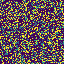
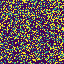

In [50]:
import mediapy as media


media.show_videos(
    media.to_rgb(out, cmap="viridis", vmin=0, vmax=1),
    titles=[f"#{i}" for i in range(out.shape[0])],
    fps=20,
    codec="gif",
    width=256,
    height=256,
)

""

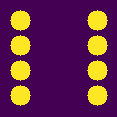

In [ ]:
import cv2
import numpy as np
import mediapy as media


def make_io_screen(H, W, r, spacing, margin, left_input, right_input):
    # left_input is an integer, draw circles on the left side of the screen
    # representing the binary representation of the input
    # the circles should be drawn vertically
    screen = np.zeros((H, W, 1), dtype=np.uint8)
    top_spacing, side_spacing = spacing

    for i in range(left_input.bit_length()):
        x = margin
        y = margin + i * spacing
        cv2.circle(screen, (x, y), r, 255, -1)

    for i in range(right_input.bit_length()):
        x = W - margin
        y = margin + i * spacing
        cv2.circle(screen, (x, y), r, 255, -1)

    return screen


res = make_io_screen(117, 117, 10, 25, 20, 10, 10)[:, :, 0]
res = media.to_rgb(res, cmap="viridis")
media.show_image(res, width=200, height=200)